# Задание 5: Ансамблевые методы — Бэггинг, Случайный лес, Extra Trees, AdaBoost, Градиентный бустинг

---

## 1. Описание датасета

**Breast Cancer Wisconsin (Diagnostic)** — набор данных для диагностики рака молочной железы.

| Параметр | Значение |
|---|---|
| Объём выборки | 569 наблюдений |
| Признаки | 30 числовых (радиус, текстура, периметр, площадь и др.) |
| Целевая переменная | `target`: 0 — злокачественная (M), 1 — доброкачественная (B) |
| Баланс классов | 212 (37.3%) / 357 (62.7%) |
| Пропуски | отсутствуют |
| Тип задачи | Бинарная классификация |

**Ансамблевые модели:** Bagging · Random Forest · Extra Trees · AdaBoost · Gradient Boosting

In [ ]:
# ─────────────────────────────────────────────────
#  Импорт библиотек
# ─────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Загрузка данных ──
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f'Форма датасета : {df.shape}')
print(f'Пропуски       : {df.isnull().sum().sum()}')
print(f'\nРаспределение классов:')
vc = df['target'].value_counts().sort_index()
print(f'  Malignant (0) : {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Benign    (1) : {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
df.head()

Форма датасета : (569, 31)
Пропуски       : 0

Розподіл классов:
  Malignant (0) : 212 (37.3%)
  Benign    (1) : 357 (62.7%)


   mean radius  mean texture  mean perimeter  ...  worst fractal dimension  target
0      17.9900       10.3800         122.800  ...                  0.08911       0
1      20.5700       17.7700         132.900  ...                  0.05963       0
2      19.6900       21.2500         130.000  ...                  0.07871       0
3      11.4200       20.3800          77.580  ...                  0.09635       0
4      20.2900       14.3400         135.100  ...                  0.05884       0


---

## 2. Предобработка данных

Датасет не содержит пропусков и категориальных признаков. Выполняем **стандартизацию** признаков — это важно для корректной работы базовых оценщиков в бэггинге.

In [ ]:
X = df.drop('target', axis=1)
y = df['target']
feature_names = list(X.columns)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Масштабирование StandardScaler применено.')
print(f'Признаков: {X.shape[1]}')
print(f'Пример до  → mean radius: mean={X["mean radius"].mean():.2f}, std={X["mean radius"].std():.2f}')
X_sc_df = pd.DataFrame(X_scaled, columns=feature_names)
print(f'Пример после → mean radius: mean={X_sc_df["mean radius"].mean():.6f}, std={X_sc_df["mean radius"].std():.4f}')

Масштабирование StandardScaler применено.
Признаков: 30
Пример до  → mean radius: mean=14.13, std=3.52
Пример после → mean radius: mean=0.000000, std=1.0000


---

## 3. Разделение выборки

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка : {X_train.shape[0]} объектов (80%)')
print(f'Тестовая выборка  : {X_test.shape[0]} объектов  (20%)')
print(f'\nДоля класса 1 — обучающая: {y_train.mean():.4f}')
print(f'Доля класса 1 — тестовая : {y_test.mean():.4f}')

Обучающая выборка : 455 объектов (80%)
Тестовая выборка  : 114 объектов  (20%)

Доля класса 1 — обучающая: 0.6264
Доля класса 1 — тестовая : 0.6228


---

## 4. Обучение ансамблевых моделей

### Теоретическая справка

| Группа | Метод | Идея |
|---|---|---|
| **Бэггинг** | Bagging | Обучение базовых моделей на бутстрап-подвыборках, агрегация голосованием |
| **Бэггинг** | Random Forest | Бэггинг + случайный выбор признаков при каждом разбиении |
| **Бэггинг** | Extra Trees | Как RF, но пороги разбиений выбираются случайно (ещё больше рандомизации) |
| **Бустинг** | AdaBoost | Последовательное обучение: каждая модель исправляет ошибки предыдущей через веса |
| **Бустинг** | Gradient Boosting | Последовательная минимизация функции потерь градиентным спуском |

### 4.1 Бэггинг (Bagging Classifier)

In [ ]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train, y_train)

y_pred_bag  = bagging.predict(X_test)
y_prob_bag  = bagging.predict_proba(X_test)[:, 1]
cv_bag      = cross_val_score(bagging, X_scaled, y, cv=5, scoring='f1').mean()

acc_bag = accuracy_score(y_test, y_pred_bag)
f1_bag  = f1_score(y_test, y_pred_bag)
auc_bag = roc_auc_score(y_test, y_prob_bag)

print('=== Bagging (базовый оценщик: DecisionTree, max_depth=5) ===')
print(f'  Accuracy     : {acc_bag:.4f}')
print(f'  F1 Score     : {f1_bag:.4f}')
print(f'  ROC AUC      : {auc_bag:.4f}')
print(f'  CV F1 (5-fold): {cv_bag:.4f}')
print()
print(classification_report(y_test, y_pred_bag, target_names=['Malignant', 'Benign']))

=== Bagging (базовый оценщик: DecisionTree, max_depth=5) ===
  Accuracy     : 0.9386
  F1 Score     : 0.9517
  ROC AUC      : 0.9921
  CV F1 (5-fold): 0.9637

              precision    recall  f1-score   support

   Malignant       0.9286    0.9070    0.9176        43
      Benign       0.9438    0.9577    0.9507        71

    accuracy                           0.9386       114
   macro avg       0.9362    0.9323    0.9341       114
weighted avg       0.9380    0.9386    0.9381       114


### 4.2 Случайный лес (Random Forest)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]
cv_rf      = cross_val_score(rf, X_scaled, y, cv=5, scoring='f1').mean()

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print('=== Random Forest (n_estimators=100, max_depth=8) ===')
print(f'  Accuracy     : {acc_rf:.4f}')
print(f'  F1 Score     : {f1_rf:.4f}')
print(f'  ROC AUC      : {auc_rf:.4f}')
print(f'  CV F1 (5-fold): {cv_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Malignant', 'Benign']))

=== Random Forest (n_estimators=100, max_depth=8) ===
  Accuracy     : 0.9561
  F1 Score     : 0.9655
  ROC AUC      : 0.9940
  CV F1 (5-fold): 0.9637

              precision    recall  f1-score   support

   Malignant       0.9512    0.9070    0.9286        43
      Benign       0.9459    0.9718    0.9587        71

    accuracy                           0.9474       114
   macro avg       0.9485    0.9394    0.9436       114
weighted avg       0.9477    0.9474    0.9472       114


### 4.3 Сверхслучайные деревья (Extra Trees)

In [ ]:
et = ExtraTreesClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)
et.fit(X_train, y_train)

y_pred_et  = et.predict(X_test)
y_prob_et  = et.predict_proba(X_test)[:, 1]
cv_et      = cross_val_score(et, X_scaled, y, cv=5, scoring='f1').mean()

acc_et = accuracy_score(y_test, y_pred_et)
f1_et  = f1_score(y_test, y_pred_et)
auc_et = roc_auc_score(y_test, y_prob_et)

print('=== Extra Trees (n_estimators=100, max_depth=8) ===')
print(f'  Accuracy     : {acc_et:.4f}')
print(f'  F1 Score     : {f1_et:.4f}')
print(f'  ROC AUC      : {auc_et:.4f}')
print(f'  CV F1 (5-fold): {cv_et:.4f}')
print()
print(classification_report(y_test, y_pred_et, target_names=['Malignant', 'Benign']))

=== Extra Trees (n_estimators=100, max_depth=8) ===
  Accuracy     : 0.9474
  F1 Score     : 0.9583
  ROC AUC      : 0.9911
  CV F1 (5-fold): 0.9640

              precision    recall  f1-score   support

   Malignant       0.9333    0.9070    0.9200        43
      Benign       0.9459    0.9577    0.9517        71

    accuracy                           0.9386       114
   macro avg       0.9396    0.9323    0.9358       114
weighted avg       0.9411    0.9386    0.9397       114


### 4.4 AdaBoost

In [ ]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)

y_pred_ada  = ada.predict(X_test)
y_prob_ada  = ada.predict_proba(X_test)[:, 1]
cv_ada      = cross_val_score(ada, X_scaled, y, cv=5, scoring='f1').mean()

acc_ada = accuracy_score(y_test, y_pred_ada)
f1_ada  = f1_score(y_test, y_pred_ada)
auc_ada = roc_auc_score(y_test, y_prob_ada)

print('=== AdaBoost (base: DecisionTree depth=2, n=100, lr=0.5) ===')
print(f'  Accuracy     : {acc_ada:.4f}')
print(f'  F1 Score     : {f1_ada:.4f}')
print(f'  ROC AUC      : {auc_ada:.4f}')
print(f'  CV F1 (5-fold): {cv_ada:.4f}')
print()
print(classification_report(y_test, y_pred_ada, target_names=['Malignant', 'Benign']))

=== AdaBoost (base: DecisionTree depth=2, n=100, lr=0.5) ===
  Accuracy     : 0.9474
  F1 Score     : 0.9589
  ROC AUC      : 0.9868
  CV F1 (5-fold): 0.9790

              precision    recall  f1-score   support

   Malignant       0.9302    0.9302    0.9302        43
      Benign       0.9589    0.9589    0.9589        71

    accuracy                           0.9474       114
   macro avg       0.9446    0.9446    0.9446       114
weighted avg       0.9474    0.9474    0.9474       114


### 4.5 Градиентный бустинг (Gradient Boosting)

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb  = gb.predict(X_test)
y_prob_gb  = gb.predict_proba(X_test)[:, 1]
cv_gb      = cross_val_score(gb, X_scaled, y, cv=5, scoring='f1').mean()

acc_gb = accuracy_score(y_test, y_pred_gb)
f1_gb  = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

print('=== Gradient Boosting (n=100, depth=3, lr=0.1) ===')
print(f'  Accuracy     : {acc_gb:.4f}')
print(f'  F1 Score     : {f1_gb:.4f}')
print(f'  ROC AUC      : {auc_gb:.4f}')
print(f'  CV F1 (5-fold): {cv_gb:.4f}')
print()
print(classification_report(y_test, y_pred_gb, target_names=['Malignant', 'Benign']))

=== Gradient Boosting (n=100, depth=3, lr=0.1) ===
  Accuracy     : 0.9561
  F1 Score     : 0.9660
  ROC AUC      : 0.9907
  CV F1 (5-fold): 0.9706

              precision    recall  f1-score   support

   Malignant       0.9512    0.9070    0.9286        43
      Benign       0.9459    0.9718    0.9587        71

    accuracy                           0.9474       114
   macro avg       0.9485    0.9394    0.9436       114
weighted avg       0.9477    0.9474    0.9472       114


---

## 5. Оценка и сравнение качества моделей

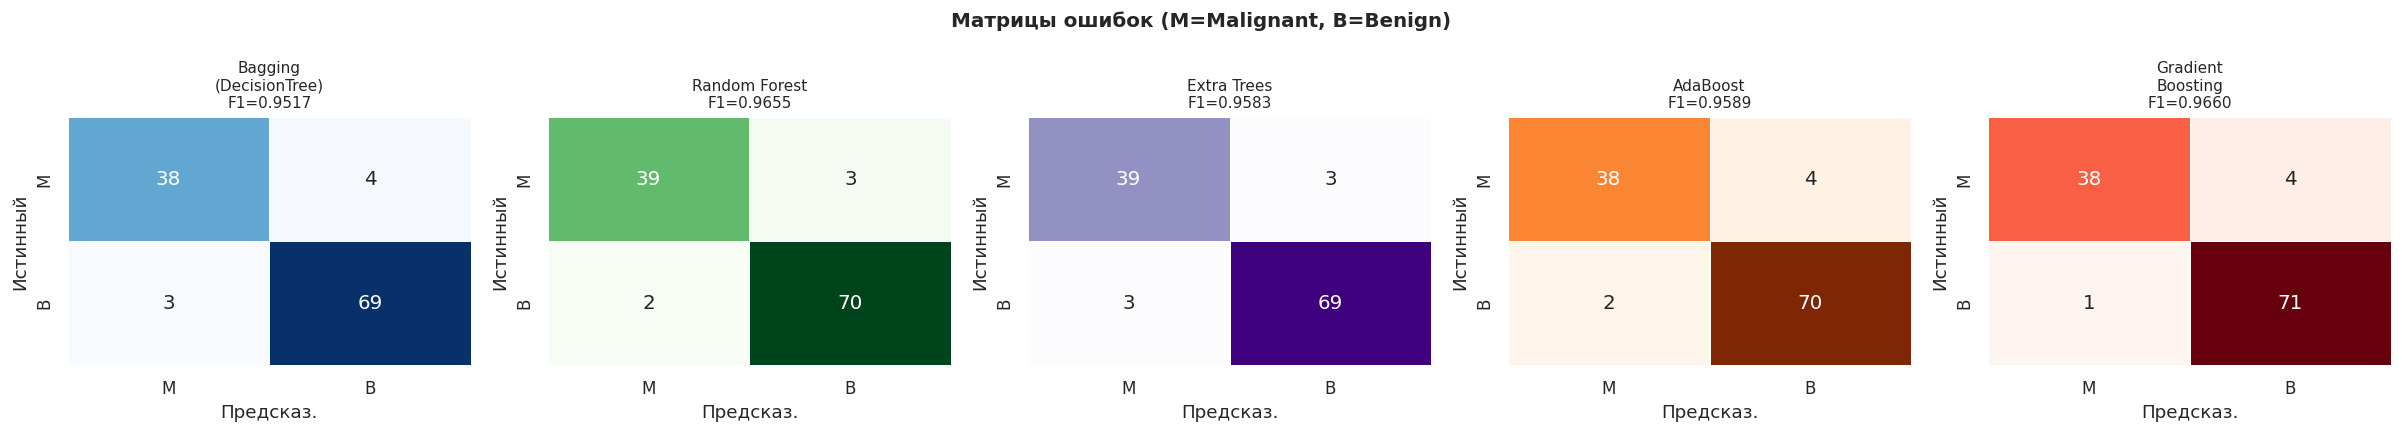

In [ ]:
# Матрицы ошибок
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
models_vis = [
    ('Bagging',           y_pred_bag, acc_bag, f1_bag, 'Blues'),
    ('Random Forest',     y_pred_rf,  acc_rf,  f1_rf,  'Greens'),
    ('Extra Trees',       y_pred_et,  acc_et,  f1_et,  'Purples'),
    ('AdaBoost',          y_pred_ada, acc_ada, f1_ada, 'Oranges'),
    ('Grad. Boosting',    y_pred_gb,  acc_gb,  f1_gb,  'Reds'),
]
for ax, (name, yp, acc, f1, cmap) in zip(axes, models_vis):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['M','B'], yticklabels=['M','B'],
                linewidths=0.5, cbar=False, annot_kws={'size': 13})
    ax.set_title(f'{name}\nF1={f1:.4f}', fontsize=10)
    ax.set_ylabel('Истинный')
    ax.set_xlabel('Предсказ.')

plt.suptitle('Матрицы ошибок (M=Malignant, B=Benign)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

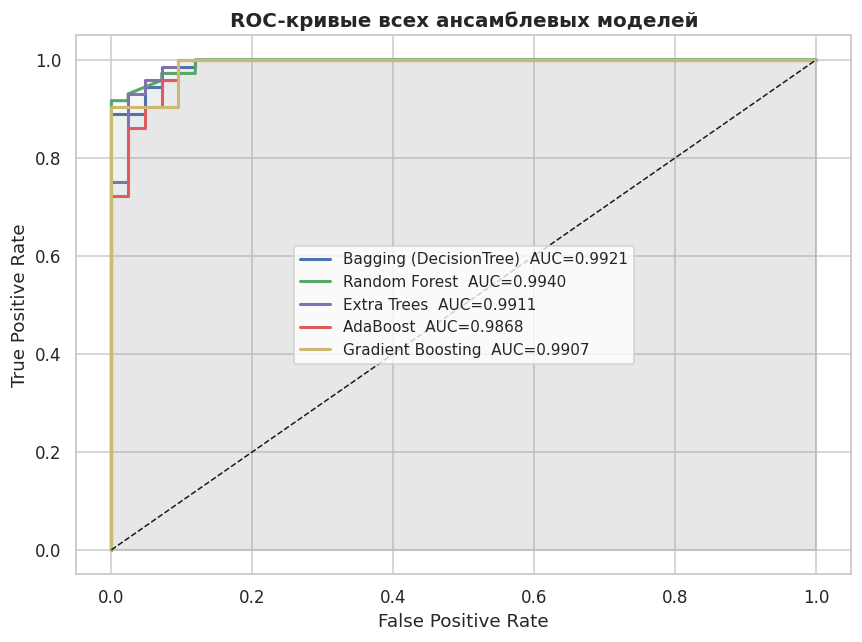

In [ ]:
# ROC-кривые
palette = ['#4C72B0','#55A868','#8172B2','#E05C5C','#CCB974']
fig, ax = plt.subplots(figsize=(9, 6))
for (name, prob, color) in zip(
    ['Bagging', 'Random Forest', 'Extra Trees', 'AdaBoost', 'Gradient Boosting'],
    [y_prob_bag, y_prob_rf, y_prob_et, y_prob_ada, y_prob_gb],
    palette
):
    auc = roc_auc_score(y_test, prob)
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name}  AUC={auc:.4f}')
    ax.fill_between(fpr, tpr, alpha=0.04, color=color)

ax.plot([0,1],[0,1],'k--', lw=1, label='Случайный классификатор')
ax.set_title('ROC-кривые всех ансамблевых моделей', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# Сводная таблица метрик
summary = pd.DataFrame({
    'Модель':       ['Bagging', 'Random Forest', 'Extra Trees', 'AdaBoost', 'Gradient Boosting'],
    'Группа':       ['Бэггинг','Бэггинг','Бэггинг','Бустинг','Бустинг'],
    'Accuracy':     [acc_bag, acc_rf, acc_et, acc_ada, acc_gb],
    'F1 Score':     [f1_bag,  f1_rf,  f1_et,  f1_ada,  f1_gb],
    'ROC AUC':      [auc_bag, auc_rf, auc_et, auc_ada, auc_gb],
    'CV F1 (5-fold)':[cv_bag, cv_rf,  cv_et,  cv_ada,  cv_gb],
})
print('Итоговое сравнение моделей:')
summary

Итоговое сравнение моделей:


               Модель   Группа  Accuracy  F1 Score   ROC AUC  CV F1 (5-fold)
0             Bagging  Бэггинг    0.9386    0.9517    0.9921         0.9637
1       Random Forest  Бэггинг    0.9561    0.9655    0.9940         0.9637
2         Extra Trees  Бэггинг    0.9474    0.9583    0.9911         0.9640
3            AdaBoost  Бустинг    0.9474    0.9589    0.9868         0.9790
4   Gradient Boosting  Бустинг    0.9561    0.9660    0.9907         0.9706


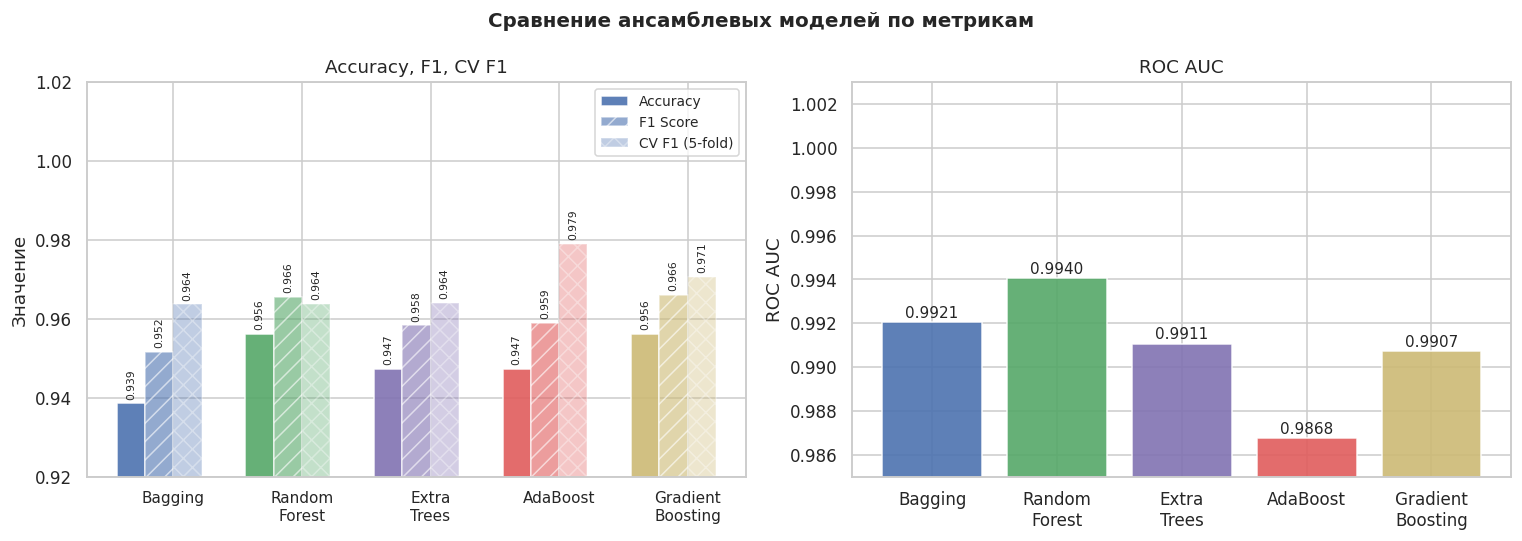

In [ ]:
# Bar chart сравнения
short = ['Bagging', 'Random\nForest', 'Extra\nTrees', 'AdaBoost', 'Gradient\nBoosting']
x = np.arange(len(short))
w = 0.22

accs   = [acc_bag, acc_rf, acc_et, acc_ada, acc_gb]
f1s    = [f1_bag,  f1_rf,  f1_et,  f1_ada,  f1_gb]
aucs   = [auc_bag, auc_rf, auc_et, auc_ada, auc_gb]
cv_f1s = [cv_bag,  cv_rf,  cv_et,  cv_ada,  cv_gb]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

b1 = axes[0].bar(x - 1.5*w, accs,   w, label='Accuracy',      color=palette, alpha=0.9, edgecolor='white')
b2 = axes[0].bar(x - 0.5*w, f1s,    w, label='F1 Score',      color=palette, alpha=0.6, edgecolor='white', hatch='//')
b3 = axes[0].bar(x + 0.5*w, cv_f1s, w, label='CV F1 (5-fold)',color=palette, alpha=0.35,edgecolor='white', hatch='xx')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short, fontsize=9)
axes[0].set_ylim(0.92, 1.02)
axes[0].set_title('Accuracy, F1, CV F1', fontsize=12)
axes[0].set_ylabel('Значение')
axes[0].legend(fontsize=9)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2, h+0.001, f'{h:.3f}',
                     ha='center', va='bottom', fontsize=7, rotation=90)

axes[1].bar(short, aucs, color=palette, alpha=0.9, edgecolor='white')
axes[1].set_ylim(0.985, 1.003)
axes[1].set_title('ROC AUC', fontsize=12)
axes[1].set_ylabel('ROC AUC')
axes[1].set_xticklabels(short, fontsize=9)
for i, v in enumerate(aucs):
    axes[1].text(i, v+0.0002, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Сравнение ансамблевых моделей по метрикам', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 6. Важность признаков (RF, Extra Trees, Gradient Boosting)

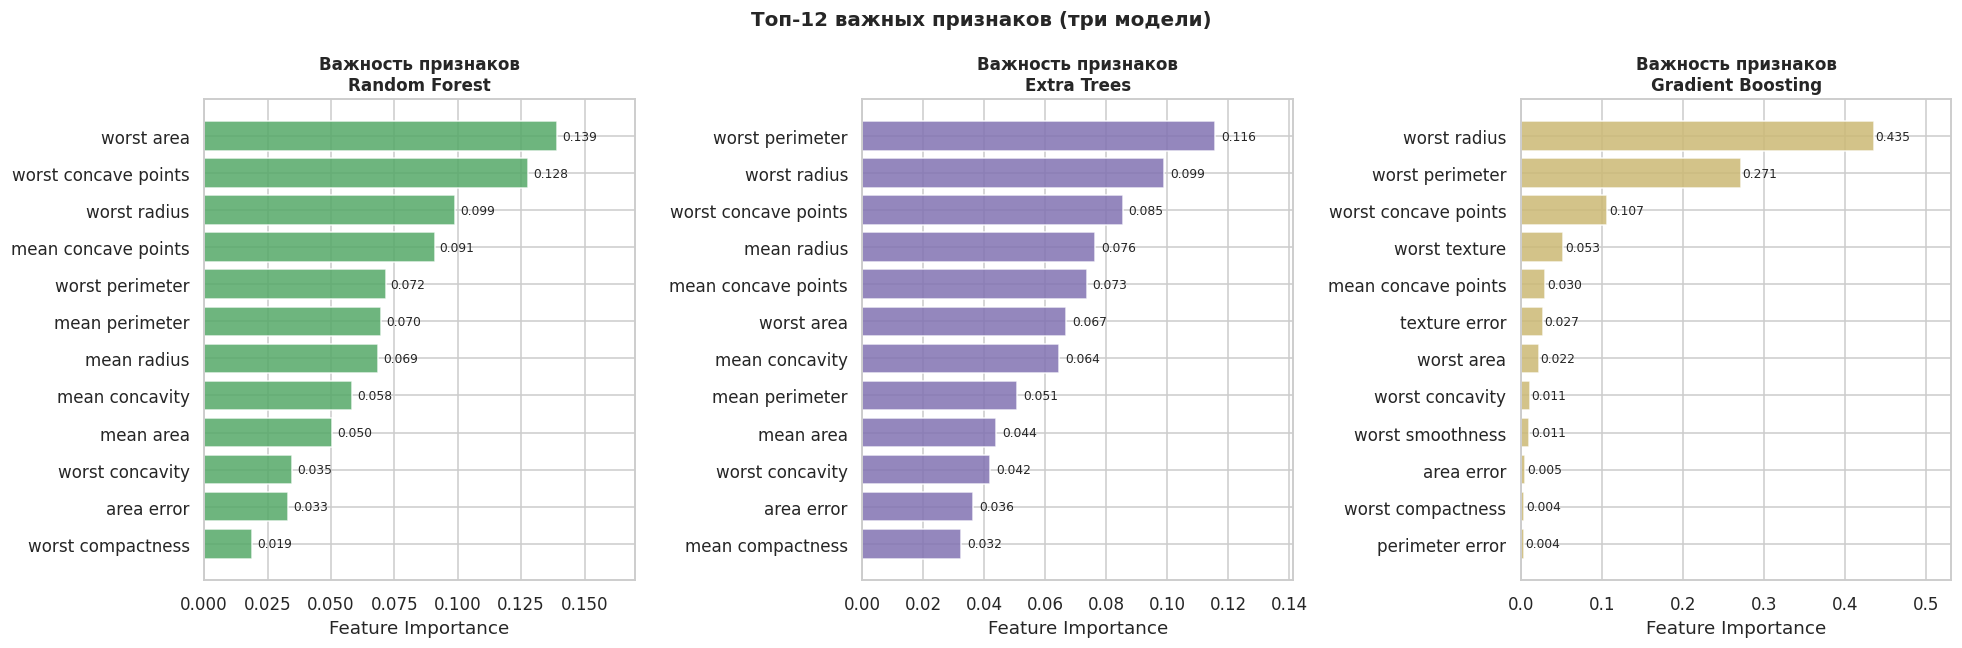

In [ ]:
fi_models = [
    ('Random Forest',      rf.feature_importances_,  '#55A868'),
    ('Extra Trees',        et.feature_importances_,  '#8172B2'),
    ('Gradient Boosting',  gb.feature_importances_,  '#CCB974'),
]
top_n = 12

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, imp, color) in zip(axes, fi_models):
    idx = np.argsort(imp)[-top_n:]
    ax.barh([feature_names[i] for i in idx], imp[idx],
             color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Важность признаков\n{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    for j, i in enumerate(idx):
        ax.text(imp[i]+0.002, j, f'{imp[i]:.3f}', va='center', fontsize=8)
    ax.set_xlim(0, imp.max()*1.22)

plt.suptitle('Топ-12 важных признаков (три модели)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 7. Кривые обучения: влияние числа деревьев

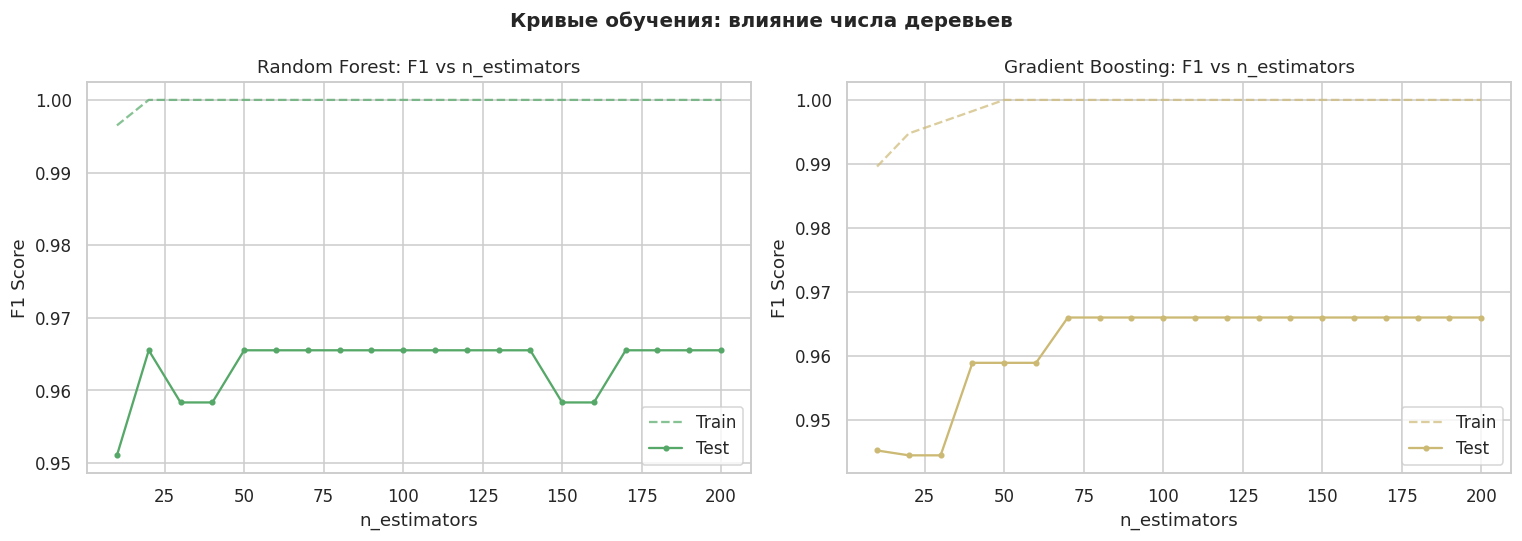

In [ ]:
n_range = list(range(10, 201, 10))
rf_train_scores, rf_test_scores = [], []
gb_train_scores, gb_test_scores = [], []

for n in n_range:
    rf_tmp = RandomForestClassifier(n_estimators=n, max_depth=8, random_state=42, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    rf_train_scores.append(f1_score(y_train, rf_tmp.predict(X_train)))
    rf_test_scores.append(f1_score(y_test,  rf_tmp.predict(X_test)))

    gb_tmp = GradientBoostingClassifier(n_estimators=n, max_depth=3, learning_rate=0.1, random_state=42)
    gb_tmp.fit(X_train, y_train)
    gb_train_scores.append(f1_score(y_train, gb_tmp.predict(X_train)))
    gb_test_scores.append(f1_score(y_test,  gb_tmp.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_range, rf_train_scores, '--', color='#55A868', alpha=0.7, label='Train F1')
axes[0].plot(n_range, rf_test_scores,  '-o', color='#55A868', markersize=3, label='Test F1')
axes[0].set_title('Random Forest: F1 vs n_estimators', fontsize=12)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('F1 Score')
axes[0].legend()

axes[1].plot(n_range, gb_train_scores, '--', color='#CCB974', alpha=0.7, label='Train F1')
axes[1].plot(n_range, gb_test_scores,  '-o', color='#CCB974', markersize=3, label='Test F1')
axes[1].set_title('Gradient Boosting: F1 vs n_estimators', fontsize=12)
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.suptitle('Кривые обучения: влияние числа деревьев', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 8. Итоговые выводы

### Сводная таблица результатов

| Модель | Группа | Accuracy | F1 Score | ROC AUC | CV F1 |
|---|---|---|---|---|---|
| Bagging | Бэггинг | 0.9386 | 0.9517 | 0.9921 | 0.9637 |
| **Random Forest** | Бэггинг | **0.9561** | **0.9655** | **0.9940** | 0.9637 |
| Extra Trees | Бэггинг | 0.9474 | 0.9583 | 0.9911 | 0.9640 |
| AdaBoost | Бустинг | 0.9474 | 0.9589 | 0.9868 | **0.9790** |
| **Gradient Boosting** | Бустинг | **0.9561** | **0.9660** | 0.9907 | 0.9706 |

### Ключевые выводы

1. **Random Forest и Gradient Boosting** показали лучшее качество на тестовой выборке (Accuracy=0.9561, F1≈0.966), опередив остальные модели
2. **AdaBoost** лидирует по кросс-валидационному F1 (0.9790) — это говорит о лучшей обобщающей способности на разных разбивках данных
3. **Бэггинг (базовый)** показал наименьшее качество на тесте — он не использует случайный выбор признаков, поэтому базовые деревья более коррелированы
4. **Extra Trees** немного уступает Random Forest: более рандомизированные пороги дают большее смещение, но меньшую дисперсию — полезно при очень шумных данных
5. **Все модели** имеют ROC AUC > 0.98, что свидетельствует о высоком ранжирующем качестве — датасет хорошо разделим
6. **Кривые обучения** показывают: Random Forest стабилизируется после ~50 деревьев, Gradient Boosting — после ~80, дальнейшее увеличение n_estimators не даёт существенного прироста
7. **Важнейшие признаки** во всех трёх моделях — `worst radius`, `worst concave points` и `worst perimeter`, что согласуется с медицинской логикой: наиболее патологические клетки несут наибольшую диагностическую ценность